# ETT Dataset — EDA for a Non-EE Building for Field Electrical Engineers

**No modeling in this notebook.** The goal is to *understand the signals* the way a substation/protection
engineer would, before building anything the product's actual users (field EEs) will judge on domain
credibility, not ML metrics.

**Data:** [ETDataset](https://github.com/zhouhaoyi/ETDataset) — `ETTh1/2.csv` (hourly), `ETTm1/2.csv` (15-min),
two power transformers.

Cells are written for a notebook environment; not executed here. Each analysis section leads with **what an
EE would look for and why** before the code, since the point of this pass is soaking in domain knowledge, not
speed.


## 1. Column glossary + the one electrical concept that unlocks this whole dataset: real vs. reactive power

- **HUFL / HULL, MUFL / MULL, LUFL / LULL** — High/Middle/Low-voltage winding taps, each split into:
  - **UFL = Useful Load** = **active (real) power**, measured in kW — the power that actually does work
    (heats a home, turns a motor). This is what a customer's bill is based on.
  - **ULL = Useless Load** = **reactive power**, measured in kVAr — power that sloshes back and forth
    magnetizing coils/transformers/motors but does no net work. "Useless" is the dataset authors' informal
    name for it; power engineers call it **Q**, and it is not actually useless — the grid needs some of it to
    maintain voltage, but too much of it wastes transformer/line capacity.
  - Together, active power `P` and reactive power `Q` form the **power triangle**: apparent power
    `S = sqrt(P² + Q²)` (kVA — what a transformer is actually rated in), and **power factor**
    `PF = P / S` (ranges 0–1, ideally close to 1). Utilities often financially penalize industrial customers
    for low power factor because it forces them to size wires/transformers for kVA nobody "pays for."
  - **This is why the dataset has 6 load columns instead of 3**: it's `(P, Q)` pairs at three voltage levels
    of one transformer, not 6 independent sensors.
- **OT — Oil Temperature.** The target signal. Oil-immersed transformers use the oil both as an insulator and
  a coolant; the top-oil temperature is what a real SCADA system trends and alarms on (typical trip setpoints
  85–105°C per IEC 60076-2, transformer-class dependent). It rises with load but with **thermal lag** — oil
  has mass and takes time to heat/cool, so OT does not track load instantaneously.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASETS = {
    "ETTh1": "ETTh1.csv",  # Transformer 1, hourly
    "ETTh2": "ETTh2.csv",  # Transformer 2, hourly
    "ETTm1": "ETTm1.csv",  # Transformer 1, 15-min
    "ETTm2": "ETTm2.csv",  # Transformer 2, 15-min
}

dfs = {}
for name, path in DATASETS.items():
    df = pd.read_csv(path, parse_dates=["date"]).set_index("date")
    dfs[name] = df
    print(name, df.shape, df.index.min(), "->", df.index.max())


ETTh1 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00
ETTh2 (17420, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:00:00
ETTm1 (69680, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:45:00
ETTm2 (69680, 7) 2016-07-01 00:00:00 -> 2018-06-26 19:45:00


## 2. First look — just plot it

Before any statistics, an EE will eyeball the raw trend the way you'd glance at a SCADA trend chart: does OT
look periodic, does it drift, are there obviously bad stretches?


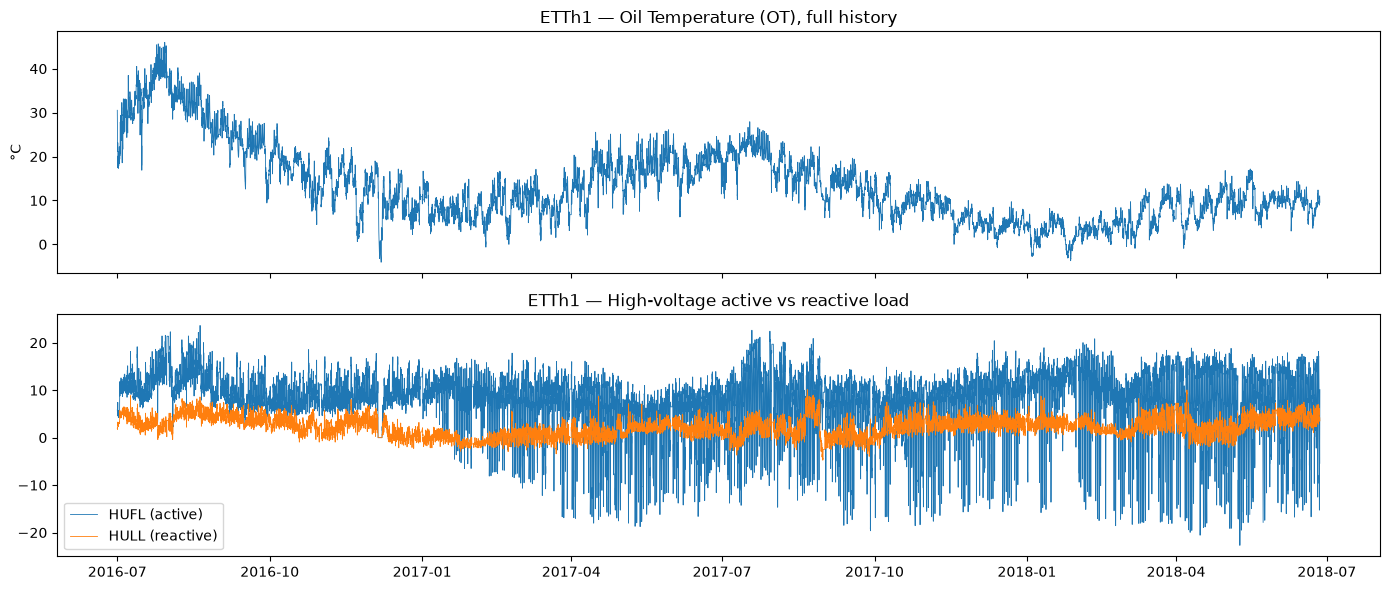

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
df = dfs["ETTh1"]
axes[0].plot(df.index, df["OT"], linewidth=0.6)
axes[0].set_title("ETTh1 — Oil Temperature (OT), full history")
axes[0].set_ylabel("°C")

axes[1].plot(df.index, df["HUFL"], label="HUFL (active)", linewidth=0.6)
axes[1].plot(df.index, df["HULL"], label="HULL (reactive)", linewidth=0.6)
axes[1].set_title("ETTh1 — High-voltage active vs reactive load")
axes[1].legend()
plt.tight_layout()


## 3. Data-quality pass (do this before trusting any pattern below)

Same checks a SCADA integrator runs on a new historian tag: is the sampling regular, are there gaps, is any
channel "stuck" (a frozen RTD or a historian tag that stopped updating but still reports "good quality")?


In [3]:
for name, df in dfs.items():
    deltas = df.index.to_series().diff().dropna()
    expected = pd.Timedelta(minutes=15) if "m" in name.lower() else pd.Timedelta(hours=1)
    n_gaps = (deltas != expected).sum()
    n_nulls = df.isna().sum().sum()
    frozen_ot_run = (df["OT"].diff() == 0).rolling(8).sum().max()
    print(f"{name}: irregular_steps={n_gaps}, nulls={n_nulls}, longest_flat_OT_run~{frozen_ot_run}")


ETTh1: irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTh2: irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTm1: irregular_steps=0, nulls=0, longest_flat_OT_run~8.0
ETTm2: irregular_steps=0, nulls=0, longest_flat_OT_run~8.0


## 4. Distributions per channel — what's a "normal" reading?

Look at `describe()` and histograms before anything time-aware. Things worth noting as a newcomer:
- **Negative values in load columns are normal** — reactive power sign indicates whether the load is
  inductive (absorbing Q, e.g. motors) or capacitive (supplying Q, e.g. capacitor banks/lightly-loaded lines).
  A negative HULL doesn't mean "broken sensor."
- **OT's range and spread** tells you the ambient climate + loading regime this transformer sits in — compare
  Transformer 1 vs 2 below, they may not be directly comparable.


In [4]:
for name, df in dfs.items():
    print(f"--- {name} ---")
    print(df.describe().T[["mean", "std", "min", "max"]])
    print()


--- ETTh1 ---
           mean       std        min        max
HUFL   7.375141  7.067744 -22.705999  23.643999
HULL   2.242242  2.042342  -4.756000  10.114000
MUFL   4.300239  6.826978 -25.087999  17.341000
MULL   0.881568  1.809293  -5.934000   7.747000
LUFL   3.066062  1.164506  -1.188000   8.498000
LULL   0.856932  0.599552  -1.371000   3.046000
OT    13.324672  8.566946  -4.080000  46.007000

--- ETTh2 ---
           mean        std      min         max
HUFL  37.193346  10.218855   0.0000  107.892998
HULL   8.537565   6.020442 -18.6800   36.438999
MUFL  43.830356  13.056798  11.2050   93.230003
MULL   8.322694   4.366059  -6.5940   28.736000
LUFL  -3.423605   6.144403 -14.3500   17.218000
LULL  -2.085969   6.012796 -31.4620    2.932000
OT    26.609376  11.888266  -2.6465   58.876999

--- ETTm1 ---
           mean       std        min     max
HUFL   7.413993  7.082928 -23.242001  24.180
HULL   2.261418  2.041293  -5.693000  10.315
MUFL   4.322226  6.829189 -26.367001  18.087
MULL   0

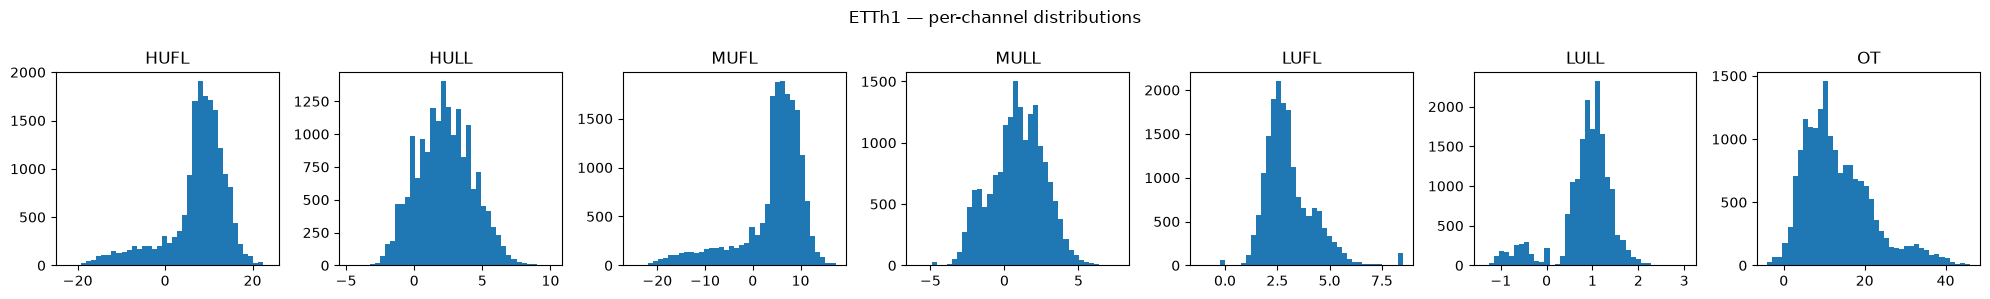

In [5]:
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
for ax, col in zip(axes, dfs["ETTh1"].columns):
    ax.hist(dfs["ETTh1"][col], bins=40)
    ax.set_title(col)
plt.suptitle("ETTh1 — per-channel distributions")
plt.tight_layout()


## 5. Seasonality — ambient temperature is a hidden variable

Oil temperature is driven by **load + ambient temperature**, and this dataset gives you load but not ambient
directly. Monthly-average OT is a decent proxy for "how much of OT's swing is just the seasons" versus
load-driven. A field EE will always ask "was that a hot July afternoon, or an actual overload event?" before
treating a temperature spike as an alarm condition.


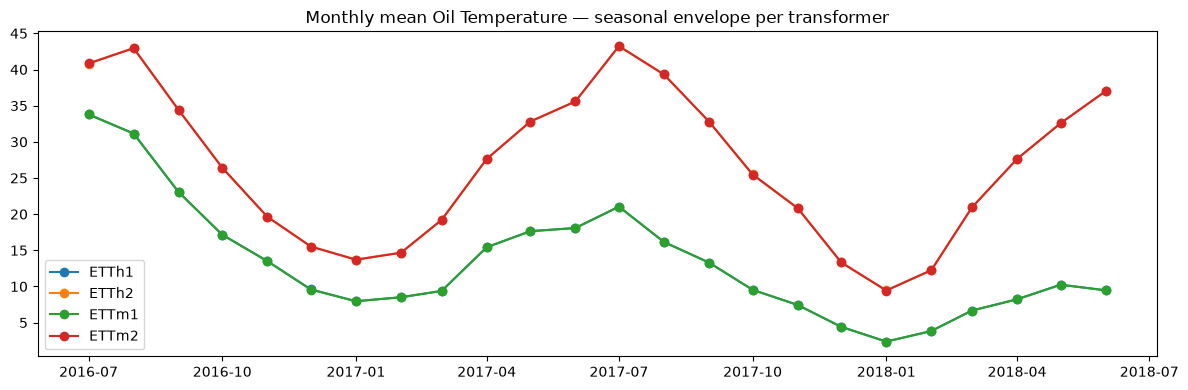

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, df in dfs.items():
    monthly = df["OT"].resample("MS").mean()
    ax.plot(monthly.index, monthly.values, marker="o", label=name)
ax.set_title("Monthly mean Oil Temperature — seasonal envelope per transformer")
ax.legend()
plt.tight_layout()


## 6. Diurnal load profile — the classic power-systems chart

Every power-systems EE has seen a "load curve by hour of day." Residential/commercial load has a strong daily
rhythm (morning ramp, evening peak); a transformer's oil temperature should show a similar rhythm, lagged by
its thermal time constant. This is the single most recognizable chart to a field EE — worth getting right.


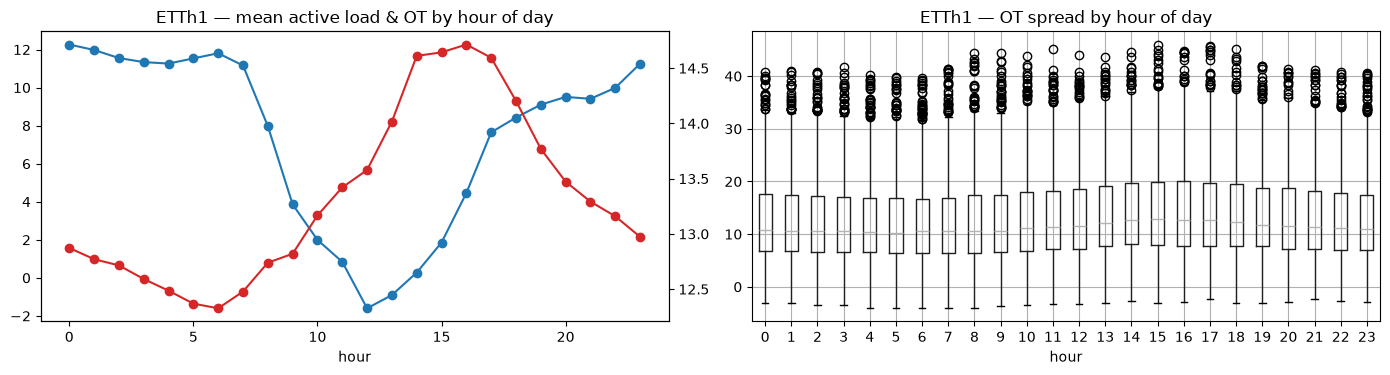

In [9]:
df = dfs["ETTh1"].copy()
df["hour"] = df.index.hour
df["is_weekend"] = df.index.dayofweek >= 5

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("hour")["HUFL"].mean().plot(ax=axes[0], marker="o", label="active (HUFL)")
df.groupby("hour")["OT"].mean().plot(ax=axes[0], marker="o", secondary_y=True, label="OT", color="tab:red")
axes[0].set_title("ETTh1 — mean active load & OT by hour of day")

df.boxplot(column="OT", by="hour", ax=axes[1])
axes[1].set_title("ETTh1 — OT spread by hour of day")
plt.suptitle("")
plt.tight_layout()


## 7. Load duration curve — how utilities actually size equipment

Instead of plotting load over time, sort it descending and plot against % of time it's met or exceeded. This
"load duration curve" is standard power-systems practice for equipment sizing: a transformer doesn't need to
be sized for average load, it needs to survive the top few % of hours. This reframes "what's a normal load"
into "what load level does this transformer actually spend most of its life below."


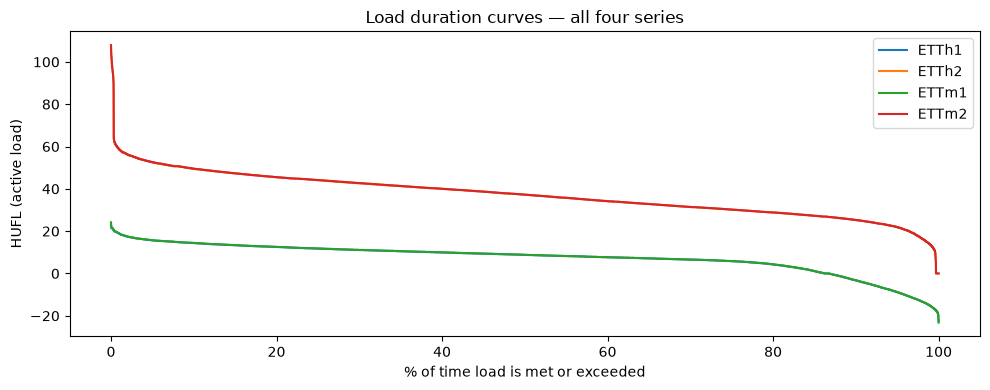

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, df in dfs.items():
    sorted_load = df["HUFL"].sort_values(ascending=False).values
    pct_time = np.linspace(0, 100, len(sorted_load))
    ax.plot(pct_time, sorted_load, label=name)
ax.set_xlabel("% of time load is met or exceeded")
ax.set_ylabel("HUFL (active load)")
ax.set_title("Load duration curves — all four series")
ax.legend()
plt.tight_layout()


## 8. Power factor — a derived signal that isn't in the raw columns but matters to EEs

`PF = P / sqrt(P² + Q²)`. Low or dropping power factor is something a field EE actively monitors (it affects
billing and effective transformer capacity), so it's worth deriving even though it's not a raw column.


In [11]:
def power_factor(df, p_col, q_col):
    p, q = df[p_col], df[q_col]
    s = np.sqrt(p**2 + q**2)
    return (p / s).replace([np.inf, -np.inf], np.nan)

for name, df in dfs.items():
    pf = power_factor(df, "HUFL", "HULL")
    print(f"{name}: HV power factor mean={pf.mean():.3f}, p05={pf.quantile(0.05):.3f}, "
          f"p95={pf.quantile(0.95):.3f}")


ETTh1: HV power factor mean=0.707, p05=-0.963, p95=1.000
ETTh2: HV power factor mean=0.968, p05=0.944, p95=1.000
ETTm1: HV power factor mean=0.707, p05=-0.962, p95=1.000
ETTm2: HV power factor mean=0.968, p05=0.944, p95=1.000


## 9. Load → OT relationship and thermal lag

The physical link the whole dataset hinges on: does active load actually predict oil temperature, and at what
lag? A scatter plot naively colored by load vs OT can look noisy *because* of the lag — the cross-correlation
at increasing lags is the right tool, and its peak is a rough estimate of the transformer's thermal time
constant (IEC 60076-7 / IEEE C57.91 territory).


ETTh1: peak HUFL->OT correlation at lag=12 steps (corr=0.136)
ETTh2: peak HUFL->OT correlation at lag=0 steps (corr=0.035)
ETTm1: peak HUFL->OT correlation at lag=48 steps (corr=0.137)
ETTm2: peak HUFL->OT correlation at lag=0 steps (corr=0.034)


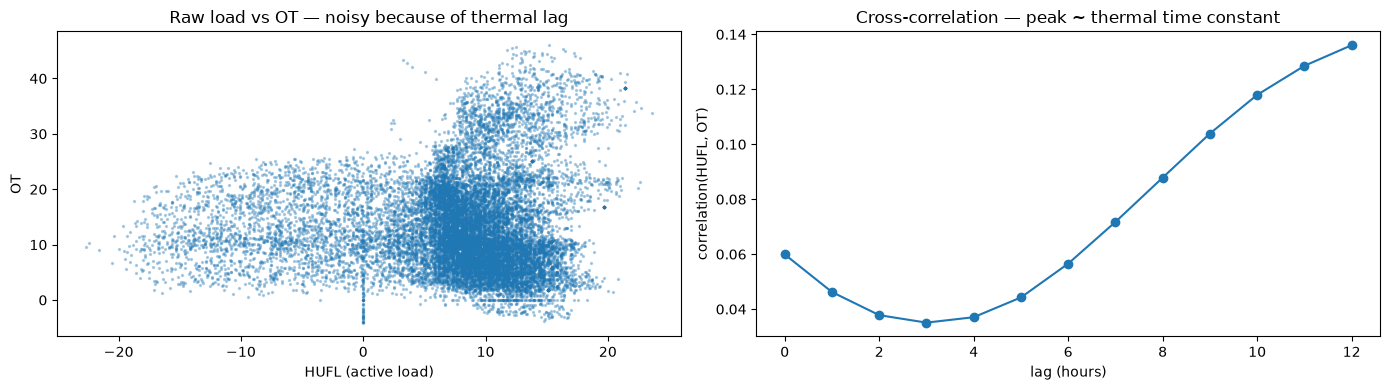

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df = dfs["ETTh1"]
axes[0].scatter(df["HUFL"], df["OT"], s=2, alpha=0.3)
axes[0].set_xlabel("HUFL (active load)")
axes[0].set_ylabel("OT")
axes[0].set_title("Raw load vs OT — noisy because of thermal lag")

def lagged_corr(df, driver="HUFL", target="OT", max_lag=12):
    return {lag: df[driver].corr(df[target].shift(-lag)) for lag in range(0, max_lag + 1)}

lc = lagged_corr(df)
axes[1].plot(list(lc.keys()), list(lc.values()), marker="o")
axes[1].set_xlabel("lag (hours)")
axes[1].set_ylabel("correlation(HUFL, OT)")
axes[1].set_title("Cross-correlation — peak ~ thermal time constant")
plt.tight_layout()

for name, df in dfs.items():
    lc = lagged_corr(df, max_lag=12 if "h" in name.lower() else 48)
    best_lag = max(lc, key=lc.get)
    print(f"{name}: peak HUFL->OT correlation at lag={best_lag} steps (corr={lc[best_lag]:.3f})")


## 10. Hourly vs 15-min sampling — same transformer, different resolution

ETTh1 and ETTm1 are (per the dataset's naming) the *same* transformer at two cadences. Resampling the 15-min
series down to hourly and comparing to the native hourly series is a good sanity check — if they don't
roughly agree, something about the two extracts isn't the same transformer/window, worth flagging before
building anything on top of the assumption that they are.


In [14]:
m1_hourly = dfs["ETTm1"]["OT"].resample("h").mean()
h1 = dfs["ETTh1"]["OT"]
common = m1_hourly.index.intersection(h1.index)
diff = (m1_hourly.loc[common] - h1.loc[common])
print(f"ETTm1-resampled-to-hourly vs ETTh1 OT: mean diff={diff.mean():.3f}, std={diff.std():.3f}, "
      f"max abs diff={diff.abs().max():.3f}")


ETTm1-resampled-to-hourly vs ETTh1 OT: mean diff=-0.004, std=0.436, max abs diff=6.577


## 11. Transformer 1 vs Transformer 2 — are they comparable?

Before building any cross-transformer feature (fleet-wide dashboards, shared alert thresholds), check whether
the two units even operate in similar regimes. Different loading levels or OT ranges would mean a single
"healthy" threshold can't apply to both.


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

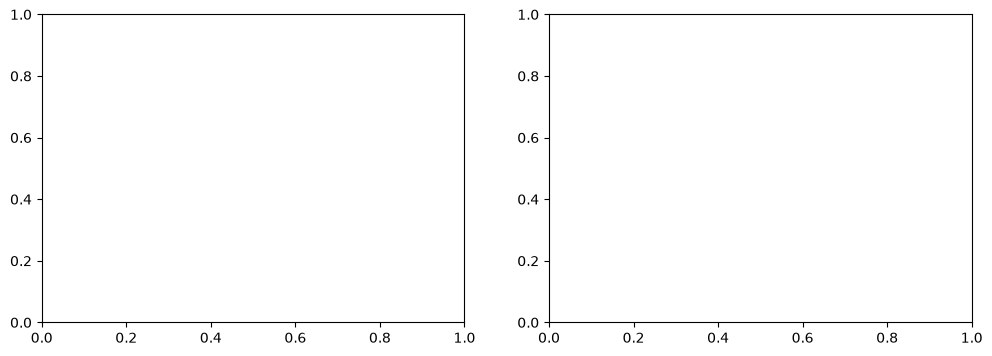

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([dfs["ETTh1"]["OT"], dfs["ETTh2"]["OT"]], labels=["Transformer 1", "Transformer 2"])
axes[0].set_title("OT distribution by transformer")

axes[1].boxplot([dfs["ETTh1"]["HUFL"], dfs["ETTh2"]["HUFL"]], labels=["Transformer 1", "Transformer 2"])
axes[1].set_title("Active load (HUFL) distribution by transformer")
plt.tight_layout()


## 12. What this EDA pass means for the product (translating EE knowledge → requirements)

Takeaways worth carrying into design decisions, before any modeling:

- **Never alarm on raw OT alone** — seasonal/ambient swings (§5) can look like a chunk of the "signal";
  a field EE will expect load-adjusted or seasonally-adjusted thresholds, not a flat trip line.
- **Respect thermal lag** (§9) — any "sudden spike" detector needs a window wide enough to not fire on normal
  lagged heating, but tight enough to catch a real fault before the IEC alarm setpoint.
- **Frozen-sensor detection (§3) is a first-class feature, not an edge case** — it's the most common real
  SCADA fault mode and silently corrupts every downstream chart if untreated.
- **Power factor (§8) is a derived metric field EEs already think in** — surfacing it (not just raw P/Q)
  will read as domain-competent rather than "another dashboard of numbers."
- **Diurnal/weekly load shape (§6) and load-duration curves (§7)** are familiar chart forms — reusing them in
  the product UI (rather than inventing new visual language) shortens the learning curve for field engineers.
- **Don't assume units/transformers are interchangeable (§11)** — per-unit baselines, not global thresholds.

No modeling performed — this is purely exploratory, per your ask. Happy to go deeper on any one section
(e.g. proper thermal-model fitting, or a real hot-spot temperature estimate per IEEE C57.91) before we touch
forecasting.
